# Exercise "math"

In this exercise I use C++ mathematical functions from `<cmath>` and `<complex>`, and I implement simple approximations to the gamma function and the logarithm of the gamma function.

The gamma-related functions are placed in a separate source file `sfuns.cc` with a header file `sfuns.h`. This file is compiled separately to an object file `sfuns.o`, which is then linked together with `main.o` to form the final executable.


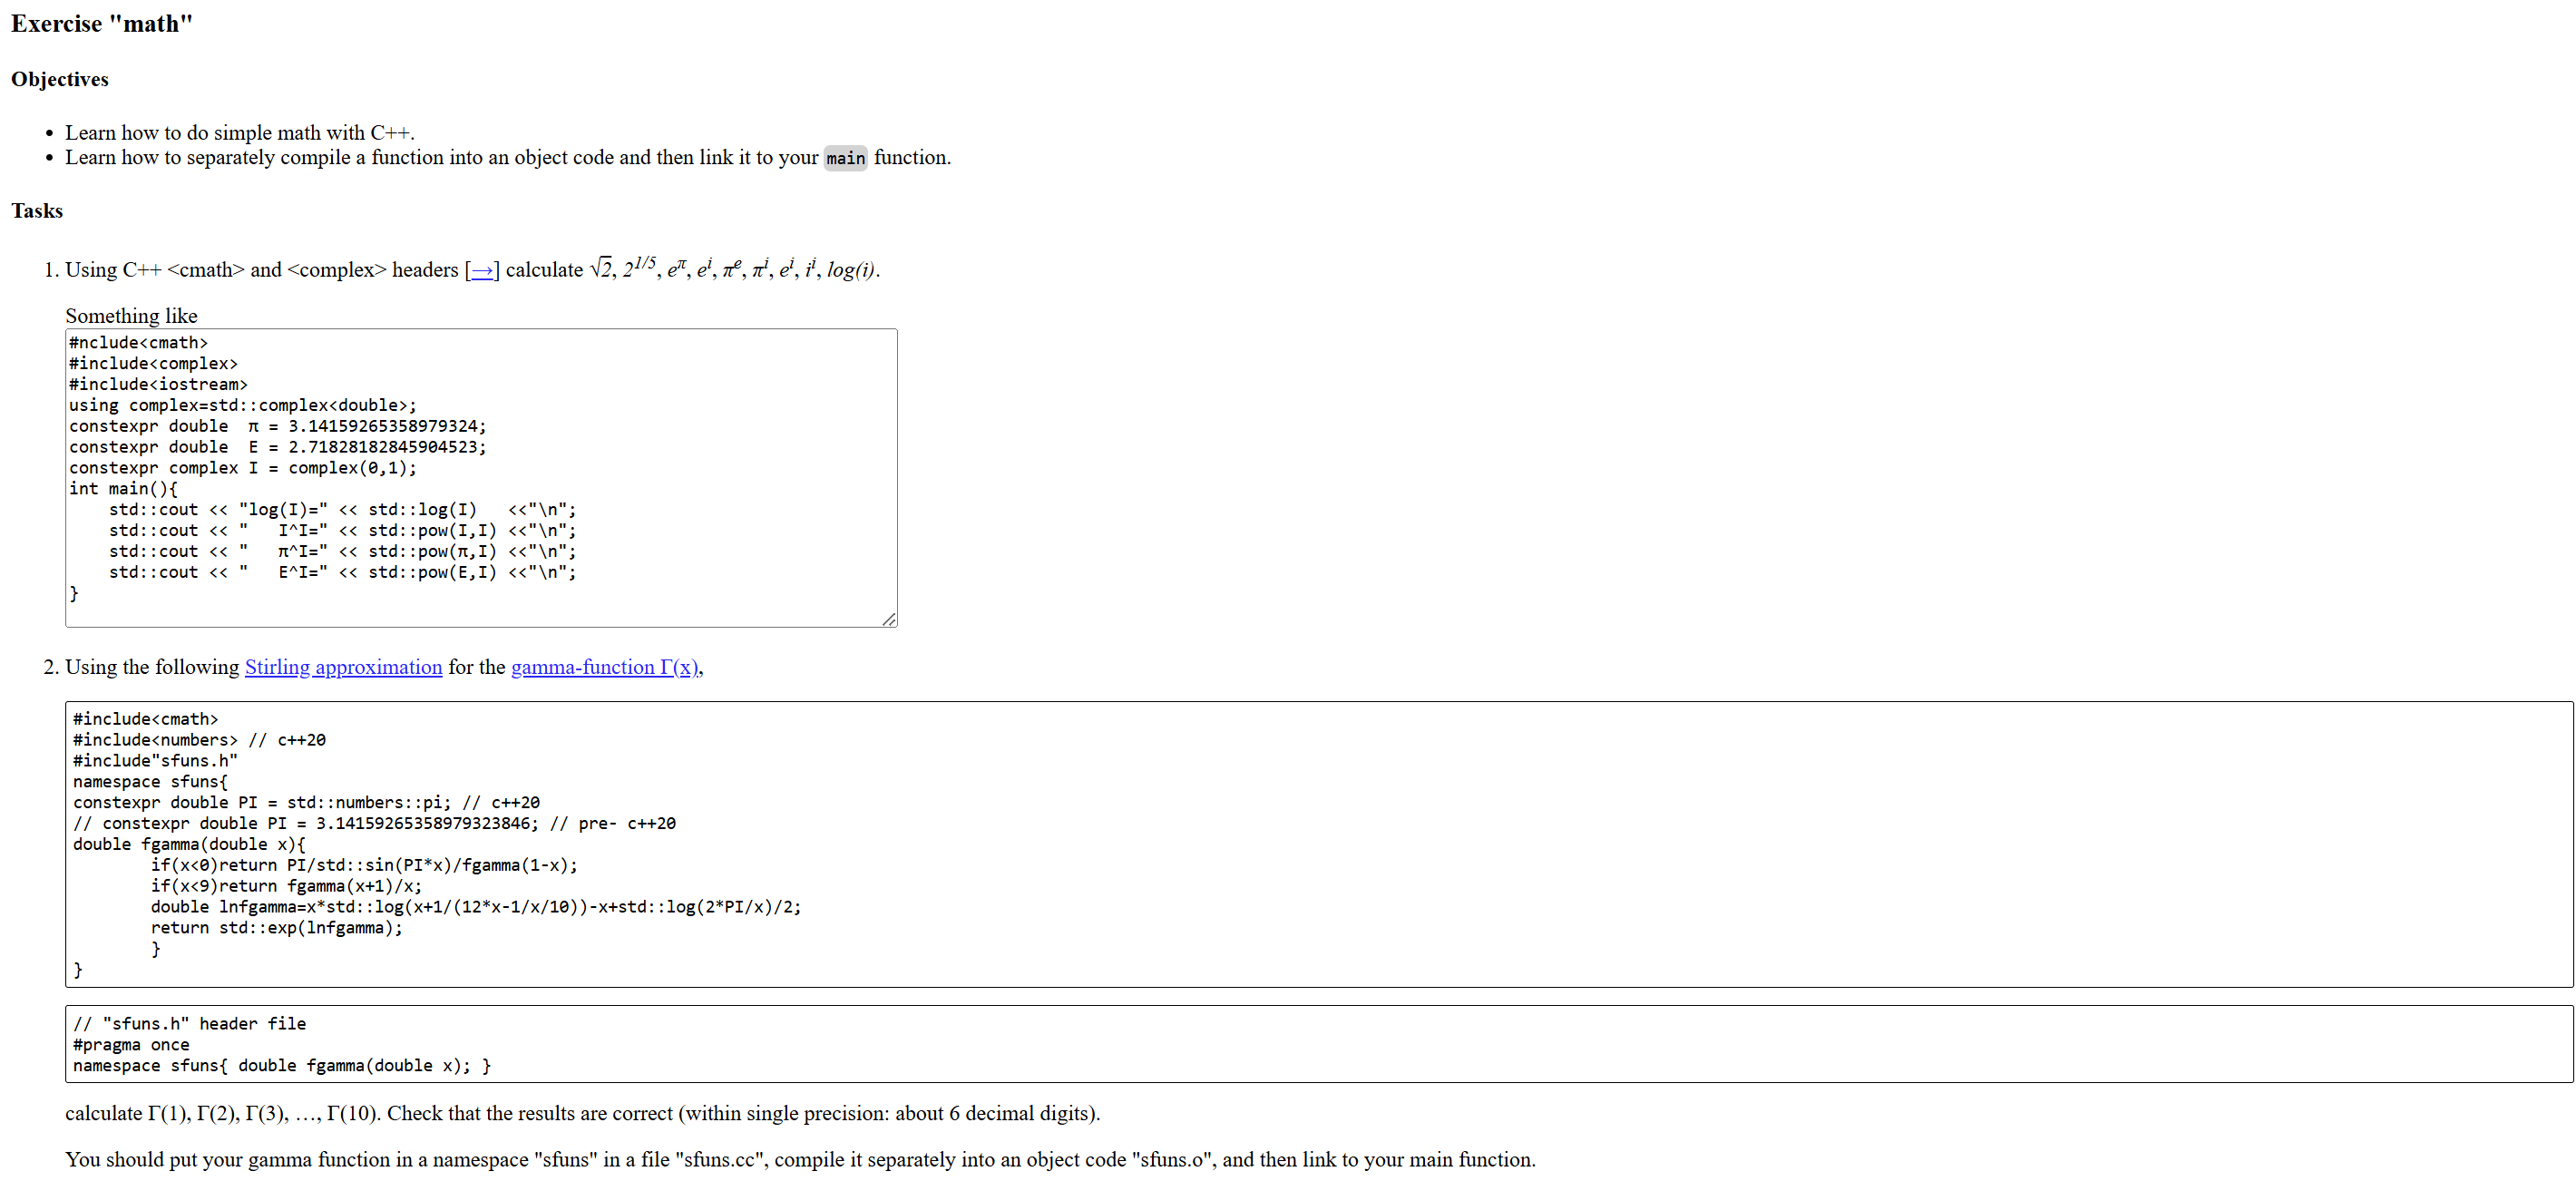

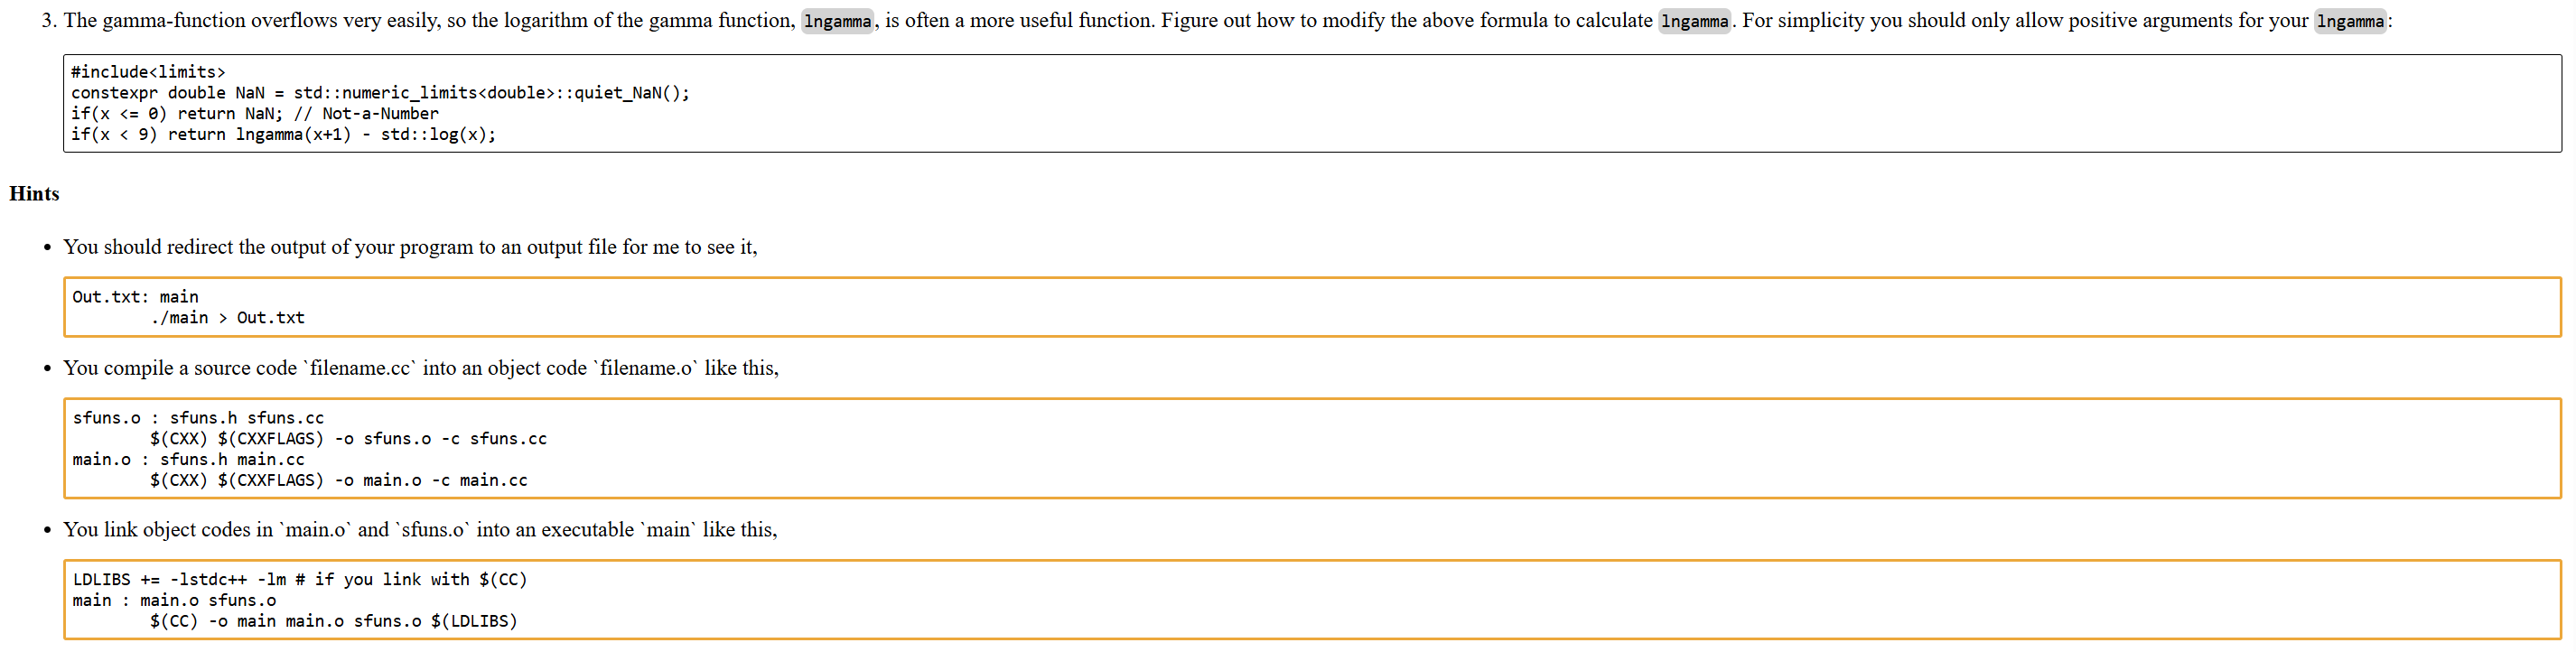

In [1]:
from pathlib import Path

Path("sfuns.h").write_text(r'''
#pragma once

namespace sfuns {
    double fgamma(double x);
    double lngamma(double x);
}
''')

print("Wrote sfuns.h")

Wrote sfuns.h


In [2]:
Path("sfuns.cc").write_text(r'''
#include "sfuns.h"

#include <cmath>
#include <limits>
#include <numbers>

namespace sfuns {

double lngamma(double x) {
    double NaN = std::numeric_limits<double>::quiet_NaN();

    if (x <= 0.0) {
        return NaN;
    }

    if (x < 9.0) {
        return lngamma(x + 1.0) - std::log(x);
    }

    double loggamma =
        x*std::log(x + 1.0/(12.0*x - 1.0/(10.0*x)))
        - x
        + std::log(2.0*std::numbers::pi/x)/2.0;

    return loggamma;
}

double fgamma(double x) {
    double pi = std::numbers::pi;

    if (x < 0.0) {
        return pi/std::sin(pi*x)/fgamma(1.0 - x);
    }

    if (x < 9.0) {
        return fgamma(x + 1.0)/x;
    }

    double loggamma =
        x*std::log(x + 1.0/(12.0*x - 1.0/(10.0*x)))
        - x
        + std::log(2.0*pi/x)/2.0;

    return std::exp(loggamma);
}

}
''')

print("Wrote sfuns.cc")

Wrote sfuns.cc


In [3]:
Path("main.cc").write_text(r'''
#include "sfuns.h"

#include <cmath>
#include <complex>
#include <iomanip>
#include <iostream>
#include <numbers>

int main() {
    using complex = std::complex<double>;

    std::cout << std::setprecision(15);

    constexpr double pi = std::numbers::pi;
    constexpr double e  = std::numbers::e;
    complex I(0.0, 1.0);

    std::cout << "Exercise math\n";
    std::cout << "-------------\n\n";

    std::cout << "Part 1: basic real and complex math\n";
    std::cout << "sqrt(2)       = " << std::sqrt(2.0) << "\n";
    std::cout << "2^(1/5)       = " << std::pow(2.0, 1.0/5.0) << "\n";
    std::cout << "e^pi          = " << std::pow(e, pi) << "\n";
    std::cout << "pi^e          = " << std::pow(pi, e) << "\n";
    std::cout << "i^i           = " << std::pow(I, I) << "\n";
    std::cout << "log(i)        = " << std::log(I) << "\n\n";

    std::cout << "Part 2: gamma function\n";
    std::cout << "n   fgamma(n)          exact (n-1)!       error\n";

    double factorial = 1.0;

    for (int n = 1; n <= 10; ++n) {
        if (n > 1) {
            factorial *= (n - 1);
        }

        double g = sfuns::fgamma(n);
        double err = std::abs(g - factorial);

        std::cout << std::setw(2) << n << "  "
                  << std::setw(16) << g << "  "
                  << std::setw(16) << factorial << "  "
                  << err << "\n";
    }

    std::cout << "\nPart 3: log-gamma function\n";
    std::cout << "x   lngamma(x)        log(fgamma(x))     std::lgamma(x)\n";

    for (int n = 1; n <= 10; ++n) {
        double x = static_cast<double>(n);

        std::cout << std::setw(2) << n << "  "
                  << std::setw(16) << sfuns::lngamma(x) << "  "
                  << std::setw(16) << std::log(sfuns::fgamma(x)) << "  "
                  << std::setw(16) << std::lgamma(x) << "\n";
    }

    return 0;
}
''')

print("Wrote main.cc")

Wrote main.cc


In [4]:
Path("Makefile").write_text(r'''
CXX = g++
CXXFLAGS = -std=c++23 -O2 -Wall -Wextra

Out.txt: main
	./main > Out.txt

main: main.o sfuns.o
	$(CXX) $(CXXFLAGS) main.o sfuns.o -o main

main.o: main.cc sfuns.h
	$(CXX) $(CXXFLAGS) -c main.cc

sfuns.o: sfuns.cc sfuns.h
	$(CXX) $(CXXFLAGS) -c sfuns.cc

clean:
	rm -f main main.o sfuns.o Out.txt
''')

print("Wrote Makefile")

Wrote Makefile


In [5]:
import subprocess

r = subprocess.run(["make"], text=True, capture_output=True)

print("make stdout:")
print(r.stdout)
print("make stderr:")
print(r.stderr)

if r.returncode == 0:
    out = Path("Out.txt").read_text()
    print(out)
else:
    print("make failed")

make stdout:
g++ -std=c++23 -O2 -Wall -Wextra -c main.cc
g++ -std=c++23 -O2 -Wall -Wextra -c sfuns.cc
g++ -std=c++23 -O2 -Wall -Wextra main.o sfuns.o -o main
./main > Out.txt

make stderr:

Exercise math
-------------

Part 1: basic real and complex math
sqrt(2)       = 1.4142135623731
2^(1/5)       = 1.14869835499704
e^pi          = 23.1406926327793
pi^e          = 22.459157718361
i^i           = (0.207879576350762,0)
log(i)        = (0,1.5707963267949)

Part 2: gamma function
n   fgamma(n)          exact (n-1)!       error
 1  0.999999989064903                 1  1.09350973831468e-08
 2  0.999999989064903                 1  1.09350973831468e-08
 3  1.99999997812981                 2  2.18701947662936e-08
 4  5.99999993438942                 6  6.56105845209254e-08
 5  23.9999997375577                24  2.62442338083702e-07
 6  119.999998687788               120  1.31221169397122e-06
 7   719.99999212673               720  7.87327019224904e-06
 8  5039.99994488711              5040  

## Exercise "math" conclusion

This exercise was completed using C++ mathematical functions from `<cmath>`, `<complex>`, and `<numbers>`.

The program calculated real and complex expressions such as $\sqrt{2}$, $2^{1/5}$, $e^\pi$, $\pi^e$, $i^i$, and $\log(i)$. The complex results were computed using `std::complex<double>`.

The gamma function was implemented in a separate source file `sfuns.cc`, declared in `sfuns.h`, compiled separately into `sfuns.o`, and linked with `main.o`. This demonstrates separate compilation and linking.

The gamma function was tested for integer arguments $n=1,\dots,10$, where the exact result is

$$
\Gamma(n) = (n-1)!.
$$

The logarithm of the gamma function was also implemented for positive arguments and compared with `std::lgamma`.

Thus, the exercise demonstrates both basic mathematical programming in C++ and the use of separate source files, object files, and linking.